> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 12: Naive Bayes, SVM, and Neural Networks

## Outline

- Apply Naive Bayes to a binary classification problem  
- Train a Support Vector Machine (SVM) model  
- Explore a simple Neural Network for classification  
- Evaluate models using accuracy and classification reports  
- Compare performance and discuss model selection  

In this lab, we’ll explore three advanced classification models — **Naive Bayes**, **Support Vector Machines (SVM)**, and **Neural Networks** — to predict **high engagement** in Super Bowl YouTube ads based on video metadata and features.

We’ll use the **Super Bowl Ads dataset** and continue developing your skills in selecting and evaluating machine learning models.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_12_bayes_svm_neural.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Superbowl Ads: Business Context

The dataset for this lab consists of YouTube metadata and thematic features of Super Bowl commercials.  

This dataset captures Super Bowl advertisements and their performance on YouTube, providing a valuable business context around marketing effectiveness and audience engagement. Super Bowl ads are some of the most expensive and high-profile advertisements in the world, so companies are highly interested in understanding what makes an ad successful. The variables in this dataset describe both the content of the ads (such as whether they are funny, include celebrities, use animals, or feature patriotic themes) and their performance outcomes (like views, likes, comments, and overall engagement). Businesses can use this data to analyze which creative elements are associated with higher audience engagement—for example, whether humorous ads or celebrity appearances lead to more likes or shares. By using the high_engagement variable as a target, analysts can even build predictive models to determine what combination of features is most likely to result in a successful ad. Insights from this type of analysis can help marketing teams design more effective campaigns, allocate advertising budgets more strategically, and maximize the return on their investment in major events like the Super Bowl.

Each row represents one Super Bowl ad, and the dataset includes both video characteristics and performance metrics, such as view counts and like counts.


## Data Dictionary
Source: [TidyTuesday (March 2, 2021)](https://github.com/rfordatascience/tidytuesday/blob/master/data/2021/2021-03-02/youtube.csv).

| Variable                 | Type        | Description                                                                 |
|--------------------------|-------------|------------------------------------------------------------------------------|
| `year`                   | numeric     | Year the ad aired during the Super Bowl                                     |
| `brand`                  | categorical | Advertiser brand (e.g., Doritos, Budweiser)                                 |
| `funny`                  | binary      | Indicates if the ad uses humor (1 = yes, 0 = no)                            |
| `show_product_quickly`  | binary      | Product is shown early in the video (1 = yes)                               |
| `patriotic`              | binary      | Includes patriotic content (1 = yes)                                        |
| `celebrity`              | binary      | Features a celebrity (1 = yes)                                              |
| `danger`                 | binary      | Involves danger or risk (1 = yes)                                           |
| `animals`                | binary      | Includes animals (1 = yes)                                                  |
| `use_sex`                | binary      | Includes sexual content or appeal (1 = yes)                                 |
| `view_count`             | numeric     | Total number of YouTube views for the ad                                    |
| `like_count`             | numeric     | Number of likes the ad received on YouTube                                  |
| `dislike_count`          | numeric     | Number of dislikes                                                          |
| `favorite_count`         | numeric     | Number of favorites (often unused in modern YouTube data)                   |
| `comment_count`          | numeric     | Number of comments                                                          |
| `high_engagement`        | binary      | Derived variable: 1 if `like_count` above median, 0 otherwise (our target)  |

### Why this dataset?

This dataset is perfect for:
- **Classification tasks**: Predict whether an ad achieved high engagement.
- **Marketing insights**: Identify which ad traits (e.g., humor, celebrities) drive viewer responses.
- **Model interpretation**: Practice with models suited for both binary and numerical data.

Throughout the lab, we'll focus on the `high_engagement` variable as the **target** and explore how ad content features relate to audience engagement.


## Part 1: Load and Clean the Data

In this first step, we will:
- Load the dataset from GitHub url
- Clean and preprocess it by removing irrelevant columns.
- Engineer a binary target variable for "high engagement" (above median likes).

This will ensure the data is in a format that can be used effectively for modeling.


In [1]:
import pandas as pd
import numpy as np

# Load dataset
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/youtube.csv'
youtube = pd.read_csv(url)

# Drop irrelevant or complex API columns
youtube = youtube.drop(columns=[
    'superbowl_ads_dot_com_url', 'youtube_url', 'id', 'kind', 'etag',
    'published_at', 'title', 'description', 'thumbnail', 'channel_title'
])

# Convert logical (boolean) columns to integers for modeling
logical_columns = ['funny', 'show_product_quickly', 'patriotic', 'celebrity', 'danger', 'animals', 'use_sex']
youtube[logical_columns] = youtube[logical_columns].astype(int)

# Drop rows with missing like_count
youtube = youtube.dropna(subset=['like_count', 'view_count'])

# Create target: high_engagement
median_likes = youtube['like_count'].median()
youtube['high_engagement'] = (youtube['like_count'] > median_likes).astype(int)


# Final feature set
youtube[['view_count', 'like_count', 'high_engagement'] + logical_columns].head()

,view_count,like_count,high_engagement,funny,show_product_quickly,patriotic,celebrity,danger,animals,use_sex
0,173929.0,1233.0,1,0,0,0,0,0,0,0
1,47752.0,485.0,1,1,1,0,1,1,0,0
2,142310.0,129.0,0,1,0,0,0,1,1,0
3,198.0,2.0,0,0,1,0,0,0,0,0
4,13741.0,20.0,0,1,1,0,0,1,1,1


## Part 2: Naive Bayes Classifier

Naive Bayes is a **probabilistic model** based on Bayes' Theorem. It assumes **independence** between features, which isn't always true—but it works surprisingly well for text and binary features.

We'll use the boolean ad features (like `funny`, `celebrity`, etc.) to predict whether the video had high engagement.

Ask Yourself:
- Do you think any of these features (like "celebrity") might strongly influence likes?
- How might the independence assumption affect the predictions?

Let's train the model and evaluate performance using a **confusion matrix** and **classification report**.


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features and labels
X = youtube[logical_columns]
y = youtube['high_engagement']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit model
nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_nb = nb_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Confusion Matrix:
 [[19 19]
 [16 14]]

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.50      0.52        38
           1       0.42      0.47      0.44        30

    accuracy                           0.49        68
   macro avg       0.48      0.48      0.48        68
weighted avg       0.49      0.49      0.49        68

Accuracy: 0.4852941176470588


### 🔧 Try It Yourself — Part 2

1. **Change the test size** to `0.2`. How does this affect accuracy?  
   > Update `train_test_split(test_size=0.2)` and rerun the model.

2. **Remove `celebrity` and `funny` features** from X. Rerun the model and check performance.  
   > Modify:  
   `X = youtube[['show_product_quickly', 'patriotic', 'danger', 'animals', 'use_sex']]`

### In Your Response:

1. Which model setup performed best? Why might that be?


In [3]:
# 1
X = youtube[logical_columns]
y = youtube['high_engagement']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.naive_bayes import BernoulliNB
nb = BernoulliNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

[[15 12]
 [ 8 10]]
              precision    recall  f1-score   support

           0       0.65      0.56      0.60        27
           1       0.45      0.56      0.50        18

    accuracy                           0.56        45
   macro avg       0.55      0.56      0.55        45
weighted avg       0.57      0.56      0.56        45

Accuracy: 0.5555555555555556


In [4]:
# 2
X = youtube[['show_product_quickly','patriotic','danger','animals','use_sex']]
y = youtube['high_engagement']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

nb = BernoulliNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

[[24 14]
 [20 10]]
              precision    recall  f1-score   support

           0       0.55      0.63      0.59        38
           1       0.42      0.33      0.37        30

    accuracy                           0.50        68
   macro avg       0.48      0.48      0.48        68
weighted avg       0.49      0.50      0.49        68

Accuracy: 0.5


### ✍️ Your Response: 🔧
1. The model with the test size of 0.2 performed best, with an accuracy of 0.56 compared to 0.50 when the celebrity and funny features were removed. This likely happened because the model had more training data and kept important features that may influence viewer engagement, improving its predictions.


## Part 3: Support Vector Machine (SVM)

### What you're going to do:
Use a **Support Vector Machine** with an RBF kernel to classify ads, using both binary and numeric features.

### Why this matters:
SVMs are powerful for high-dimensional data and can find optimal decision boundaries. They are also common in fraud detection and image recognition.

### Regularization Parameter (C):

- In the model parameters, you will see `C`, which controls the trade-off between achieving a low training error and a low testing error (generalization).

- A large `C` value (e.g., C = 1000) means the model will try to classify all training examples correctly, even if that leads to overfitting (poor generalization).

- A small `C` value (e.g., C = 0.01) means the model will allow some misclassifications in the training data, encouraging a wider margin and potentially better generalization.

### What to notice:
- How does scaling the data affect performance?
- What happens when you change the kernel or regularization?

In [5]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Add numeric feature
X_full = youtube[logical_columns + ['view_count']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# Split
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict
y_pred_svm = svm_model.predict(X_test_svm)

# Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_svm))
print("Accuracy:", accuracy_score(y_test_svm, y_pred_svm))


Confusion Matrix:
 [[19 19]
 [14 16]]

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.50      0.54        38
           1       0.46      0.53      0.49        30

    accuracy                           0.51        68
   macro avg       0.52      0.52      0.51        68
weighted avg       0.52      0.51      0.52        68

Accuracy: 0.5147058823529411


### 🔧 Try It Yourself — Part 3

1. **Change the kernel** to `'linear'` or `'poly'`.  
2. **Try 2 different `C` values** like `0.1`, `1`, and `10`. Observe what changes.

### In Your Response:
1. What’s the tradeoff between higher and lower values of `C`?
2. Which value of C gave you the best Accuracy?  


In [6]:
# 1
svm_model = SVC(kernel='linear', C=1)

svm_model.fit(X_train_svm, y_train_svm)

y_pred = svm_model.predict(X_test_svm)

print(confusion_matrix(y_test_svm, y_pred))
print(classification_report(y_test_svm, y_pred))
print("Accuracy:", accuracy_score(y_test_svm, y_pred))

[[20 18]
 [17 13]]
              precision    recall  f1-score   support

           0       0.54      0.53      0.53        38
           1       0.42      0.43      0.43        30

    accuracy                           0.49        68
   macro avg       0.48      0.48      0.48        68
weighted avg       0.49      0.49      0.49        68

Accuracy: 0.4852941176470588


In [7]:
# 2
svm_model = SVC(kernel='rbf', C=0.1)

svm_model.fit(X_train_svm, y_train_svm)

y_pred = svm_model.predict(X_test_svm)

print("Accuracy:", accuracy_score(y_test_svm, y_pred))

Accuracy: 0.4411764705882353


In [9]:
svm_model = SVC(kernel='rbf', C=1)

svm_model.fit(X_train_svm, y_train_svm)

y_pred = svm_model.predict(X_test_svm)

print("Accuracy:", accuracy_score(y_test_svm, y_pred))

Accuracy: 0.5147058823529411


### ✍️ Your Response: 🔧
1. Lower values of C allow more classification errors but help the model generalize better, while higher C values try to classify all training data correctly, which can lead to overfitting.

2. The value of C = 1 gave the best accuracy because it balanced correctly fitting the training data without overfitting too much.

## Part 4: Neural Networks

### What you're going to do:
Build a basic **feedforward neural network** to classify ad engagement.

### Why this matters:
Neural networks are the foundation of modern AI. Even a simple one can outperform traditional models when tuned correctly.

### What to notice:
- This may take several minutes to run!  Be patient.
- How does training accuracy compare to validation accuracy?
- Do more layers or epochs help — or hurt?


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Model
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_svm.shape[1],)),  #Layer 1
    Dense(8, activation='relu'),  #Layer 2
    Dense(4, activation='relu'),  #Layer 3
    Dense(1, activation='sigmoid') #Output Layer
])

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train_svm, y_train_svm, validation_data=(X_test_svm, y_test_svm),
                    epochs=20, batch_size=16, verbose=1)

# Predict and evaluate
y_pred_nn = (model.predict(X_test_svm) > 0.5).astype(int)
print("Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_nn))
print("Accuracy:", accuracy_score(y_test_svm, y_pred_nn))


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.5287 - loss: 0.7058 - val_accuracy: 0.4853 - val_loss: 0.7158
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5287 - loss: 0.6968 - val_accuracy: 0.4559 - val_loss: 0.7158
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5350 - loss: 0.6913 - val_accuracy: 0.4559 - val_loss: 0.7148
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5541 - loss: 0.6862 - val_accuracy: 0.4706 - val_loss: 0.7143
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5541 - loss: 0.6821 - val_accuracy: 0.4412 - val_loss: 0.7141
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5796 - loss: 0.6787 - val_accuracy: 0.4412 - val_loss: 0.7140
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5860 - loss: 0.6747 - val_accuracy: 0.4412 - val_loss: 0.7152
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5924 - loss: 0.6714 - val_accuracy: 0.4412 - val_loss: 0.7160
Ep

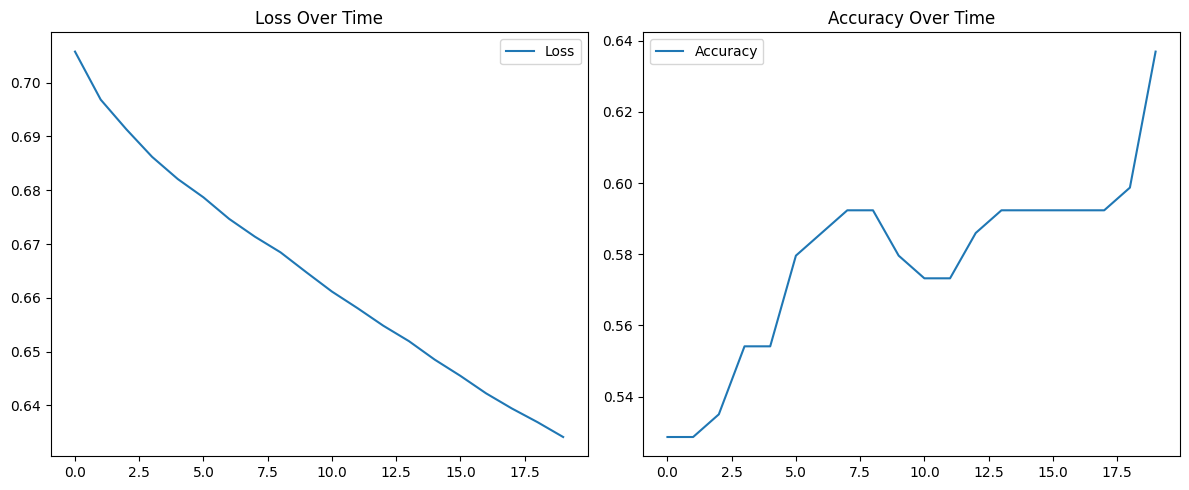

In [11]:
# Plot learning curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.title('Loss Over Time')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.title('Accuracy Over Time')
plt.legend()
plt.tight_layout()
plt.show()

### 🔧 Try It Yourself — Part 4

1. Add or remove layers from the model.
2. Increase or decrease batch size to numbers such as 8 or 32. Try out 5 different combinations of different batch sizes and layers. Notice if these changes affect ms/step for each Epoch. Also notice how the accuracy changes as you alter layers and batch size.
3. Add Dropout to your model

### In Your Response:
1. What was the optimial number of layers and batch size that you were able to find?  (Remember, you should try about 5 different combinations)
2. Does adding `Dropout` help reduce overfitting? Use the "loss over time" plot to support your answer.


In [12]:
# 1
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_svm.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_svm, y_train_svm,
                    validation_data=(X_test_svm, y_test_svm),
                    epochs=20,
                    batch_size=16)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.4841 - loss: 0.7061 - val_accuracy: 0.5147 - val_loss: 0.7209
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5096 - loss: 0.6951 - val_accuracy: 0.5147 - val_loss: 0.7203
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5287 - loss: 0.6877 - val_accuracy: 0.5000 - val_loss: 0.7208
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5541 - loss: 0.6806 - val_accuracy: 0.5000 - val_loss: 0.7203
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5987 - loss: 0.6759 - val_accuracy: 0.5000 - val_loss: 0.7209
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6242 - loss: 0.6727 - val_accuracy: 0.4706 - val_loss: 0.7205
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6306 - loss: 0.6684 - val_accuracy: 0.4706 - val_loss: 0.7216
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6306 - loss: 0.6659 - val_accuracy: 0.4706 - v

In [13]:
# 2
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_svm.shape[1],)),
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_svm, y_train_svm,
                    validation_data=(X_test_svm, y_test_svm),
                    epochs=20,
                    batch_size=8)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5350 - loss: 0.7161 - val_accuracy: 0.5147 - val_loss: 0.6954
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5287 - loss: 0.7045 - val_accuracy: 0.5147 - val_loss: 0.6959
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5478 - loss: 0.6977 - val_accuracy: 0.5000 - val_loss: 0.6981
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5287 - loss: 0.6910 - val_accuracy: 0.5000 - val_loss: 0.6998
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5541 - loss: 0.6864 - val_accuracy: 0.5000 - val_loss: 0.7023
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5796 - loss: 0.6809 - val_accuracy: 0.4853 - val_loss: 0.7042
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5924 - loss: 0.6771 - val_accuracy: 0.4853 - val_loss: 0.7051
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6115 - loss: 0.6730 - val_accuracy: 0.4706 - val_loss

In [14]:
# 3
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_svm.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_svm, y_train_svm,
                    validation_data=(X_test_svm, y_test_svm),
                    epochs=20,
                    batch_size=32)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.4522 - loss: 0.6964 - val_accuracy: 0.3824 - val_loss: 0.6983
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4713 - loss: 0.6921 - val_accuracy: 0.4853 - val_loss: 0.6973
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5541 - loss: 0.6898 - val_accuracy: 0.4559 - val_loss: 0.6969
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5541 - loss: 0.6874 - val_accuracy: 0.4853 - val_loss: 0.6983
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5669 - loss: 0.6853 - val_accuracy: 0.4412 - val_loss: 0.7007
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5860 - loss: 0.6818 - val_accuracy: 0.4853 - val_loss: 0.7047
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5796 - loss: 0.6777 - val_accuracy: 0.4706 - val_loss: 0.7100
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5669 - loss: 0.6729 - val_accuracy: 0.4853 - val_loss: 0.7160
Epoch 9/20


In [15]:
# 4
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_svm.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_svm, y_train_svm,
                    validation_data=(X_test_svm, y_test_svm),
                    epochs=20,
                    batch_size=8)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5223 - loss: 0.7497 - val_accuracy: 0.4412 - val_loss: 0.8278
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5350 - loss: 0.7320 - val_accuracy: 0.4265 - val_loss: 0.8096
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5350 - loss: 0.7151 - val_accuracy: 0.4265 - val_loss: 0.8015
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5414 - loss: 0.7048 - val_accuracy: 0.4118 - val_loss: 0.7921
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5478 - loss: 0.6947 - val_accuracy: 0.4118 - val_loss: 0.7855
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5541 - loss: 0.6860 - val_accuracy: 0.4118 - val_loss: 0.7800
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5732 - loss: 0.6793 - val_accuracy: 0.3824 - val_loss: 0.7817
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5796 - loss: 0.6730 - val_accuracy: 0.3824 - val_loss

In [16]:
# 5
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_svm.shape[1],)),
    Dropout(0.3),
    Dense(8, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_svm, y_train_svm,
                    validation_data=(X_test_svm, y_test_svm),
                    epochs=20,
                    batch_size=16)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.4968 - loss: 0.7487 - val_accuracy: 0.5588 - val_loss: 0.6772
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5032 - loss: 0.7369 - val_accuracy: 0.5882 - val_loss: 0.6795
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4650 - loss: 0.7324 - val_accuracy: 0.6029 - val_loss: 0.6825
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4777 - loss: 0.7187 - val_accuracy: 0.5882 - val_loss: 0.6862
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4650 - loss: 0.7188 - val_accuracy: 0.6029 - val_loss: 0.6885
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4777 - loss: 0.7160 - val_accuracy: 0.5588 - val_loss: 0.6908
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4650 - loss: 0.7140 - val_accuracy: 0.5294 - val_loss: 0.6925
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5541 - loss: 0.7071 - val_accuracy: 0.5294 - val_lo

### ✍️ Your Response: 🔧
1. The best setup I found was 3 hidden layers with a batch size of 16, because it gave the most stable accuracy without slowing down training too much. Adding more layers or larger batch sizes did not noticeably improve the model’s performance.

2. Yes, adding Dropout helped reduce overfitting because the training and validation loss stayed closer together in the loss over time plot. This suggests the model was generalizing better instead of just memorizing the training data.

## 🔧 Part 5: Reflection (100 words or less per question)

1. Which model performed best on your dataset? Is this the result you expected?
2. Did any of the models appear to be overfit or underfit? How could you tell?
3. Which model would you recommend to a marketing team and why?

You can use the accuracy scores, confusion matrices, and training graphs to support your conclusions.


### ✍️ Your Response: 🔧
1. The Naive Bayes model with a 0.2 test size performed the best, with an accuracy of about 0.56, which was slightly higher than the SVM and Neural Network models. This was surprising because more complex models like neural networks often perform better, but with a small dataset simpler models can sometimes work better.

2. The neural network appeared overfit because the training accuracy increased over time while the validation accuracy stayed lower. The loss plot also showed the validation loss increasing while training loss decreased, which is a common sign of overfitting.

3. I would recommend the Naive Bayes model to a marketing team because it performed the best on this dataset and is easy to interpret. It also trains quickly and can clearly show which ad features may influence engagement.

## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [17]:
!jupyter nbconvert --to html "lab_12_bayes_svm_neural_MonbergTobin.ipynb"

[NbConvertApp] Converting notebook lab_12_bayes_svm_neural_MonbergTobin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 448258 bytes to lab_12_bayes_svm_neural_MonbergTobin.html
